In [174]:
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.cm as cm

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [176]:
fff = np.linspace(20, 10000, 1000)
y = np.ones_like(fff)*0.1

In [ ]:
def apply_spec_idx(data, freq,
           spec_idx=-1.7, ref_freq=400,
           lft=False, beta=1.8, fc=70,
           bpl=False, spec_idx_2=-1.59, fb=1400):
    '''
    Given an input array `data` labeled by input vector `freq`, 
    apply a spectral index to modulate the amplitude of `data` over frequency.

    Here we assume that the first dimension of data is frequency.
    There is no assumption as to the other dimensions; 
    `data` can be 2D (freq, time) or 3D (freq, pol, time).

    lft: Does the pulsar spectrum have a low-frequency turnover (LFT)? If so, set to True.
    beta: Used only if LFT = True to set the smoothness of the turnover; see Jankowski+18.
    fc: Used only if LFT = True to set the turnover frequency [MHz].

    By default, spec_idx=-1.7 and ref_freq=400 (MHz), as is appropriate for
    PSR J0630-2834 per Jankowski+18.

    TODO: Simulate log-parabolic spectra.
    '''
    gains = np.array([(f/ref_freq)**spec_idx for f in freq])

    if lft == True:
        turnover_gains = np.array([np.exp((spec_idx/beta) * (f/fc)**(-1*beta)) for f in freq])
        gains *= turnover_gains
    if bpl == True:
        gains = []
        for f in freq:
            if f < fb:
                gains.append((f/ref_freq)**spec_idx)
            else:
                gains.append(((f/ref_freq)**spec_idx_2) * (fb/ref_freq)**(spec_idx-spec_idx_2))
        gains = np.array(gains)
    
    data2 = data * gains[:,None]
    return data2

In [170]:
y_lft = apply_spec_idx(y, fff, lft=True)
y_simple = apply_spec_idx(y, fff, lft=False)

In [27]:
print(fff.shape)
print(y_lft.shape)

(1000,)
(1000, 1000)


In [32]:
betas = np.arange(0.3, 2.11, 0.3)
print(betas)

[0.3 0.6 0.9 1.2 1.5 1.8 2.1]


/var/folders/b_/601lqv7d3mg79nf_9cc89gd40000gn/T/ipykernel_4298/1308806225.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Reds_r')
/var/folders/b_/601lqv7d3mg79nf_9cc89gd40000gn/T/ipykernel_4298/1308806225.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([None,None,'100', '1000',None])


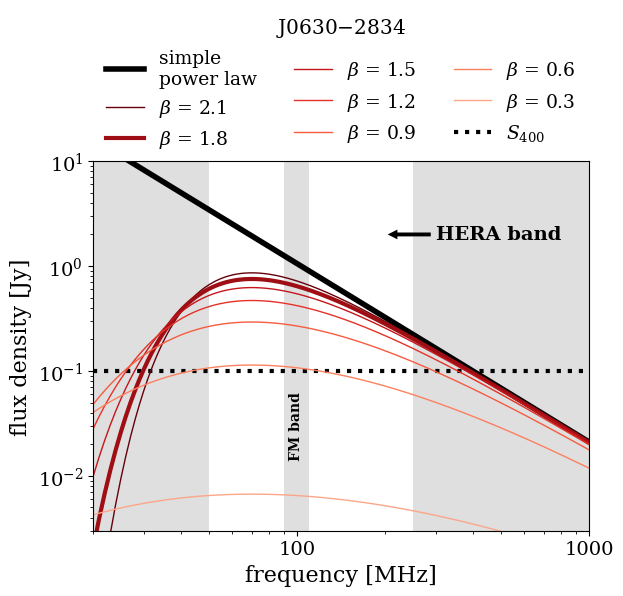

In [173]:
plt.plot(fff, y_simple[:,0], c='k', lw=4, label='simple\npower law', zorder=2)

cmap = cm.get_cmap('Reds_r')

for i, beta in enumerate(betas[::-1]):
    if beta==1.8:
        lw=3
    else:
        lw=1
    y_lft = apply_spec_idx(y, fff, lft=True, beta=beta)
    plt.plot(fff, y_lft[:,0], color=cmap(0.8*i/len(betas)), lw=lw, zorder=2, label=rf'$\beta$ = {beta:.2}')

plt.plot(fff, y, color='k', ls=':', lw=3, label='$S_{400}$', zorder=1)

plt.xlabel('frequency [MHz]', size=16)
plt.ylabel('flux density [Jy]', size=16)
plt.gca().tick_params(axis='both', labelsize=14)
plt.yscale('log')
plt.xscale('log')
forbidden_alpha = 0.25
forbidden_color = 'grey'
plt.axvspan(20, 50, color=forbidden_color, alpha=forbidden_alpha, lw=0, zorder=0)
plt.axvspan(90, 110, color=forbidden_color, alpha=forbidden_alpha, lw=0, zorder=0)
plt.axvspan(250, 1000, color=forbidden_color, alpha=forbidden_alpha, lw=0, zorder=0)
# plt.xticks([20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500,
#             600, 700, 800, 900, 1000])
# plt.gca().set_xticklabels([None, None, None, 50, None, None, None, None, 100, 
#                            None, None, None, None, None, None, None, None, 1000])
plt.ylim(0.003, 10)
plt.xlim(fff[0], fff[-1])
#plt.axvline(50, color='grey', ls='--')
#plt.axvline(250, color='grey', ls='--')
plt.annotate('HERA band', (200, 2), (300, 2), xycoords='data', textcoords='data',
             arrowprops={'arrowstyle':'simple', 'linewidth':0,
                         'color':'k'}, va='center', size=14, weight='bold')
plt.text(np.sqrt(90*110), 0.015, 'FM band', weight='bold', rotation=90, ha='center', zorder=5)
plt.legend(ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.21), loc='center', fontsize=13.5,
           title='J0630$-$2834', title_fontsize=14.5)
#print(plt.gca().get_xticklabels())
plt.gca().set_xticklabels([None,None,'100', '1000',None])
# plt.savefig('/Users/user/Downloads/Fig_beta_smoothness.pdf', bbox_inches='tight')
plt.show()

[Text(1.0, 0, '$\\mathdefault{10^{0}}$'), Text(10.0, 0, '$\\mathdefault{10^{1}}$'), Text(100.0, 0, '$\\mathdefault{10^{2}}$'), Text(1000.0, 0, '$\\mathdefault{10^{3}}$'), Text(10000.0, 0, '$\\mathdefault{10^{4}}$'), Text(100000.0, 0, '$\\mathdefault{10^{5}}$')]


/var/folders/b_/601lqv7d3mg79nf_9cc89gd40000gn/T/ipykernel_4298/2971798513.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([None,None,'100', '1000', '10000', None, None])


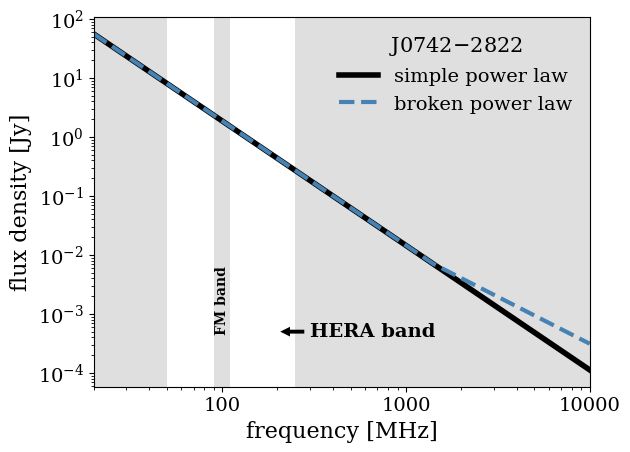

In [185]:
y_simple = apply_spec_idx(y, fff, -2.11, 400)

y_bpl = apply_spec_idx(y, fff, -2.11, 400, bpl=True, spec_idx_2=-1.59, fb=1400)

plt.plot(fff, y_simple[:,0], c='k', lw=4, label='simple power law', zorder=2)
plt.plot(fff, y_bpl[:,0], color='steelblue', lw=3, ls='--', zorder=2, label='broken power law')
plt.axvspan(20, 50, color=forbidden_color, alpha=forbidden_alpha, lw=0, zorder=0)
plt.axvspan(90, 110, color=forbidden_color, alpha=forbidden_alpha, lw=0, zorder=0)
plt.axvspan(250, 10000, color=forbidden_color, alpha=forbidden_alpha, lw=0, zorder=0)
plt.xlim(20, 10000)
plt.xscale('log')
plt.yscale('log')
print(plt.gca().get_xticklabels())
plt.gca().set_xticklabels([None,None,'100', '1000', '10000', None, None])
plt.xlabel('frequency [MHz]', size=16)
plt.ylabel('flux density [Jy]', size=16)
plt.gca().tick_params(axis='both', labelsize=14)
plt.legend(title='J0742$-$2822', frameon=False, fontsize=14, title_fontsize=15)
plt.annotate('HERA band', (200, 0.0005), (300, 0.0005), xycoords='data', textcoords='data',
             arrowprops={'arrowstyle':'simple', 'linewidth':0,
                         'color':'k'}, va='center', size=14, weight='bold')
plt.text(np.sqrt(90*110), 0.0005, 'FM band', weight='bold', rotation=90, ha='center', zorder=5)
plt.savefig('/Users/user/Downloads/Fig_broken_power_law.pdf', bbox_inches='tight')
plt.show()

In [166]:
plt.legend?

Signature: plt.legend(*args, **kwargs) -> 'Legend'
Docstring:
Place a legend on the Axes.

Call signatures::

    legend()
    legend(handles, labels)
    legend(handles=handles)
    legend(labels)

The call signatures correspond to the following different ways to use
this method:

**1. Automatic detection of elements to be shown in the legend**

The elements to be added to the legend are automatically determined,
when you do not pass in any extra arguments.

In this case, the labels are taken from the artist. You can specify
them either at artist creation or by calling the
:meth:`~.Artist.set_label` method on the artist::

    ax.plot([1, 2, 3], label='Inline label')
    ax.legend()

or::

    line, = ax.plot([1, 2, 3])
    line.set_label('Label via method')
    ax.legend()

.. note::
    Specific artists can be excluded from the automatic legend element
    selection by using a label starting with an underscore, "_".
    A string starting with an underscore is the default label for a